# CISB5123 Text Analytics - Lab Assignment 2

**Student Name:**
`<ALSAKKAF MUSAAB>`
 `<HASHEM MUSAAB>`
`<MOUSAB MOHAMMED>`  

**Student ID:** 
`<SW01083207>` 
`<SW01084071>`
`<SW01084034>`



## Assignment coverage

- Data preprocessing on the Amazon Fine Food Reviews dataset
- Feature extraction with TF-IDF
- Sentiment classification using a lexicon-based model and machine-learning models
- Model evaluation with accuracy, weighted F1-score, classification report, and confusion matrix
- Short discussion of strengths and weaknesses


## Generated results summary

- Extracted dataset size: **50,000** reviews
- Class distribution: negative=7,216, neutral=3,750, positive=39,034
- Train/test split: **40,000 / 10,000**
- Best model: **LinearSVC**
- Best model accuracy: **0.8823**
- Best model weighted F1-score: **0.8691**

In [15]:
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")

BASE_DIR = Path(".")
SOURCE_CSV = BASE_DIR / "Reviews.csv"
EXTRACTED_CSV = BASE_DIR / "amazon_fine_food_reviews_50000.csv"
RANDOM_STATE = 42
SAMPLE_SIZE = 50000
LABEL_ORDER = ["negative", "neutral", "positive"]


In [16]:
def score_to_sentiment(score: int) -> str:
    if score <= 2:
        return "negative"
    if score == 3:
        return "neutral"
    return "positive"


clean_re = re.compile(r"[^a-zA-Z\s]")
space_re = re.compile(r"\s+")


def clean_text(text: str) -> str:
    text = str(text).lower()
    text = clean_re.sub(" ", text)
    text = space_re.sub(" ", text).strip()
    return text


In [17]:
if EXTRACTED_CSV.exists():
    sampled_df = pd.read_csv(EXTRACTED_CSV)
else:
    full_df = pd.read_csv(SOURCE_CSV, usecols=["Score", "Summary", "Text"])
    full_df["Summary"] = full_df["Summary"].fillna("")
    full_df["Text"] = full_df["Text"].fillna("")
    full_df["sentiment"] = full_df["Score"].apply(score_to_sentiment)
    full_df["review_text"] = (full_df["Summary"].astype(str) + " " + full_df["Text"].astype(str)).str.strip()
    full_df = full_df[full_df["review_text"].str.len() > 0].copy()

    sampled_df, _ = train_test_split(
        full_df,
        train_size=SAMPLE_SIZE,
        random_state=RANDOM_STATE,
        stratify=full_df["sentiment"],
    )

    sampled_df = sampled_df.copy()
    sampled_df["clean_text"] = sampled_df["review_text"].apply(clean_text)
    sampled_df.to_csv(EXTRACTED_CSV, index=False)

sampled_df["Summary"] = sampled_df["Summary"].fillna("")
sampled_df["Text"] = sampled_df["Text"].fillna("")
sampled_df["review_text"] = sampled_df["review_text"].fillna("").astype(str)
sampled_df["clean_text"] = sampled_df["clean_text"].fillna("").astype(str)
sampled_df = sampled_df[sampled_df["clean_text"].str.len() > 0].copy()

print(f"Extracted dataset path: {EXTRACTED_CSV}")
print(f"Rows in extracted dataset: {len(sampled_df):,}")
sampled_df.head()


Extracted dataset path: amazon_fine_food_reviews_50000.csv
Rows in extracted dataset: 50,000


,Score,Summary,Text,sentiment,review_text,clean_text
0,5,Fresh & worth buying in bulk even if you don't use very often,I usually just buy pine nuts bulk from Amazon based on price. These fit the bill. Actually easier to store than th...,positive,Fresh & worth buying in bulk even if you don't use very often I usually just buy pine nuts bulk from Amazon based on...,fresh worth buying in bulk even if you don t use very often i usually just buy pine nuts bulk from amazon based on p...
1,5,I really LOVE this stuff!,When I realized I was allergic to artificial sweetener I thought my days of drinking calorie and sugar free drinks w...,positive,I really LOVE this stuff! When I realized I was allergic to artificial sweetener I thought my days of drinking calor...,i really love this stuff when i realized i was allergic to artificial sweetener i thought my days of drinking calori...
2,3,Inconsistent Quality,"I first tasted this tea about 6 months ago, bought it in a grocery store in Philadelphia's Chinatown, 25 bags for ab...",neutral,"Inconsistent Quality I first tasted this tea about 6 months ago, bought it in a grocery store in Philadelphia's Chin...",inconsistent quality i first tasted this tea about months ago bought it in a grocery store in philadelphia s chinato...
3,4,Nice Breakfast blend with perky aroma,Aroma-4<br />Great nutty smell that will be pleasing in the morning.<br /><br />Sweetness-3<br />There is defiantly ...,positive,Nice Breakfast blend with perky aroma Aroma-4<br />Great nutty smell that will be pleasing in the morning.<br /><br ...,nice breakfast blend with perky aroma aroma br great nutty smell that will be pleasing in the morning br br sweetnes...
4,5,Delishious!,What I like the best about this product is that it does not contain caffeine yet still has that great fizz to it. A...,positive,Delishious! What I like the best about this product is that it does not contain caffeine yet still has that great fi...,delishious what i like the best about this product is that it does not contain caffeine yet still has that great fiz...


In [18]:
class_distribution = sampled_df["sentiment"].value_counts().reindex(LABEL_ORDER)
class_percent = (class_distribution / len(sampled_df) * 100).round(2)

distribution_df = pd.DataFrame({
    "count": class_distribution,
    "percentage": class_percent,
})
distribution_df


,count,percentage
sentiment,,
negative,7216,14.43
neutral,3750,7.50
positive,39034,78.07


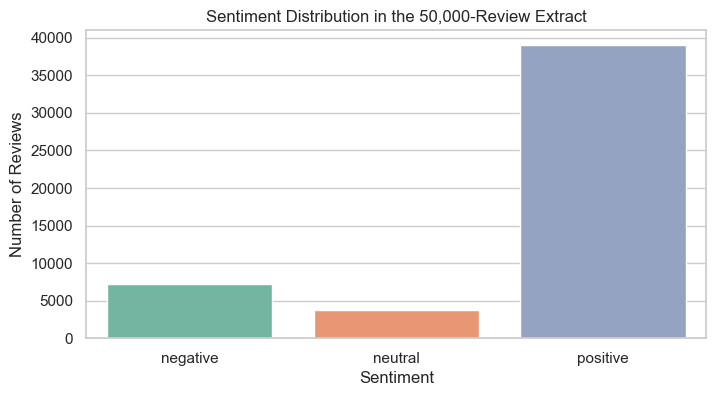

In [19]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=sampled_df, x="sentiment", order=LABEL_ORDER, palette="Set2")
ax.set_title("Sentiment Distribution in the 50,000-Review Extract")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Number of Reviews")
plt.show()


In [20]:
sampled_df["text_length"] = sampled_df["clean_text"].str.split().str.len()
sampled_df["text_length"].describe()


count    50000.000000
mean        86.974360
std         83.042089
min          8.000000
25%         37.000000
50%         61.000000
75%        106.000000
max       1849.000000
Name: text_length, dtype: float64

In [21]:
train_df, test_df = train_test_split(
    sampled_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=sampled_df["sentiment"],
)

print(f"Training set size: {len(train_df):,}")
print(f"Test set size: {len(test_df):,}")


Training set size: 40,000
Test set size: 10,000


In [22]:
import nltk
nltk.download("vader_lexicon")

sia = SentimentIntensityAnalyzer()

def vader_predict(text: str) -> str:
    score = sia.polarity_scores(text)["compound"]
    if score >= 0.05:
        return "positive"
    if score <= -0.05:
        return "negative"
    return "neutral"


vader_pred = test_df["clean_text"].apply(vader_predict)


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Void2\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [23]:
results = []
reports = {}
confusions = {}


def evaluate_model(model_name: str, y_true, y_pred):
    results.append(
        {
            "model": model_name,
            "accuracy": accuracy_score(y_true, y_pred),
            "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        }
    )
    reports[model_name] = classification_report(y_true, y_pred, output_dict=True)
    confusions[model_name] = confusion_matrix(y_true, y_pred, labels=LABEL_ORDER)


evaluate_model("VADER Lexicon", test_df["sentiment"], vader_pred)
pd.DataFrame(results)


,model,accuracy,weighted_f1
0,VADER Lexicon,0.8181,0.781838


In [24]:
models = {
    "MultinomialNB": MultinomialNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "LinearSVC": LinearSVC(),
}

fitted_models = {}

for model_name, classifier in models.items():
    pipeline = Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    stop_words="english",
                    max_features=20000,
                    ngram_range=(1, 2),
                    min_df=3,
                ),
            ),
            ("classifier", classifier),
        ]
    )
    pipeline.fit(train_df["clean_text"], train_df["sentiment"])
    predictions = pipeline.predict(test_df["clean_text"])
    fitted_models[model_name] = pipeline
    evaluate_model(model_name, test_df["sentiment"], predictions)

results_df = pd.DataFrame(results).sort_values(
    by=["weighted_f1", "accuracy"], ascending=False
).reset_index(drop=True)
results_df


,model,accuracy,weighted_f1
0,LinearSVC,0.8823,0.869133
1,LogisticRegression,0.8761,0.854047
2,VADER Lexicon,0.8181,0.781838
3,MultinomialNB,0.8219,0.766652


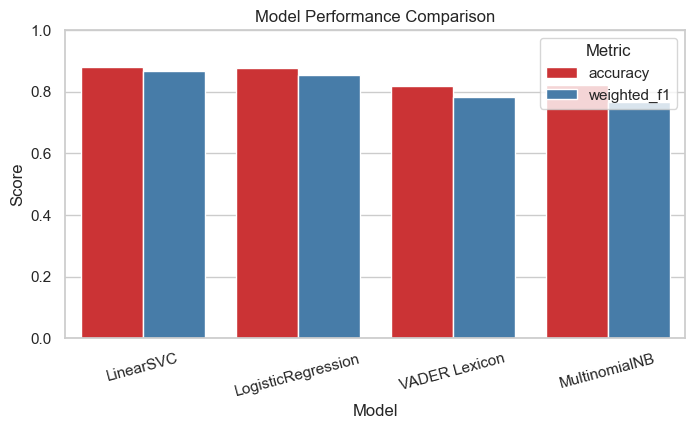

In [25]:
plt.figure(figsize=(8, 4))
plot_df = results_df.melt(id_vars="model", value_vars=["accuracy", "weighted_f1"], var_name="metric", value_name="score")
ax = sns.barplot(data=plot_df, x="model", y="score", hue="metric", palette="Set1")
ax.set_title("Model Performance Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="Metric")
plt.show()


In [26]:
for model_name in results_df["model"]:
    print(f"\n{model_name}")
    report_df = pd.DataFrame(reports[model_name]).transpose()
    display(report_df.loc[LABEL_ORDER + ["accuracy", "macro avg", "weighted avg"]].round(4))



LinearSVC


,precision,recall,f1-score,support
negative,0.7784,0.7207,0.7485,1443.0000
neutral,0.5697,0.2560,0.3533,750.0000
positive,0.9116,0.9723,0.9410,7807.0000
accuracy,0.8823,0.8823,0.8823,0.8823
macro avg,0.7533,0.6497,0.6809,10000.0000
weighted avg,0.8668,0.8823,0.8691,10000.0000



LogisticRegression


,precision,recall,f1-score,support
negative,0.8090,0.6632,0.7289,1443.0000
neutral,0.5938,0.1520,0.2420,750.0000
positive,0.8916,0.9850,0.9360,7807.0000
accuracy,0.8761,0.8761,0.8761,0.8761
macro avg,0.7648,0.6001,0.6356,10000.0000
weighted avg,0.8573,0.8761,0.8540,10000.0000



VADER Lexicon


,precision,recall,f1-score,support
negative,0.6678,0.4248,0.5193,1443.0000
neutral,0.1460,0.0267,0.0451,750.0000
positive,0.8438,0.9668,0.9011,7807.0000
accuracy,0.8181,0.8181,0.8181,0.8181
macro avg,0.5525,0.4728,0.4885,10000.0000
weighted avg,0.7661,0.8181,0.7818,10000.0000



MultinomialNB


,precision,recall,f1-score,support
negative,0.8834,0.2994,0.4472,1443.0000
neutral,0.0000,0.0000,0.0000,750.0000
positive,0.8188,0.9974,0.8993,7807.0000
accuracy,0.8219,0.8219,0.8219,0.8219
macro avg,0.5674,0.4323,0.4489,10000.0000
weighted avg,0.7667,0.8219,0.7667,10000.0000


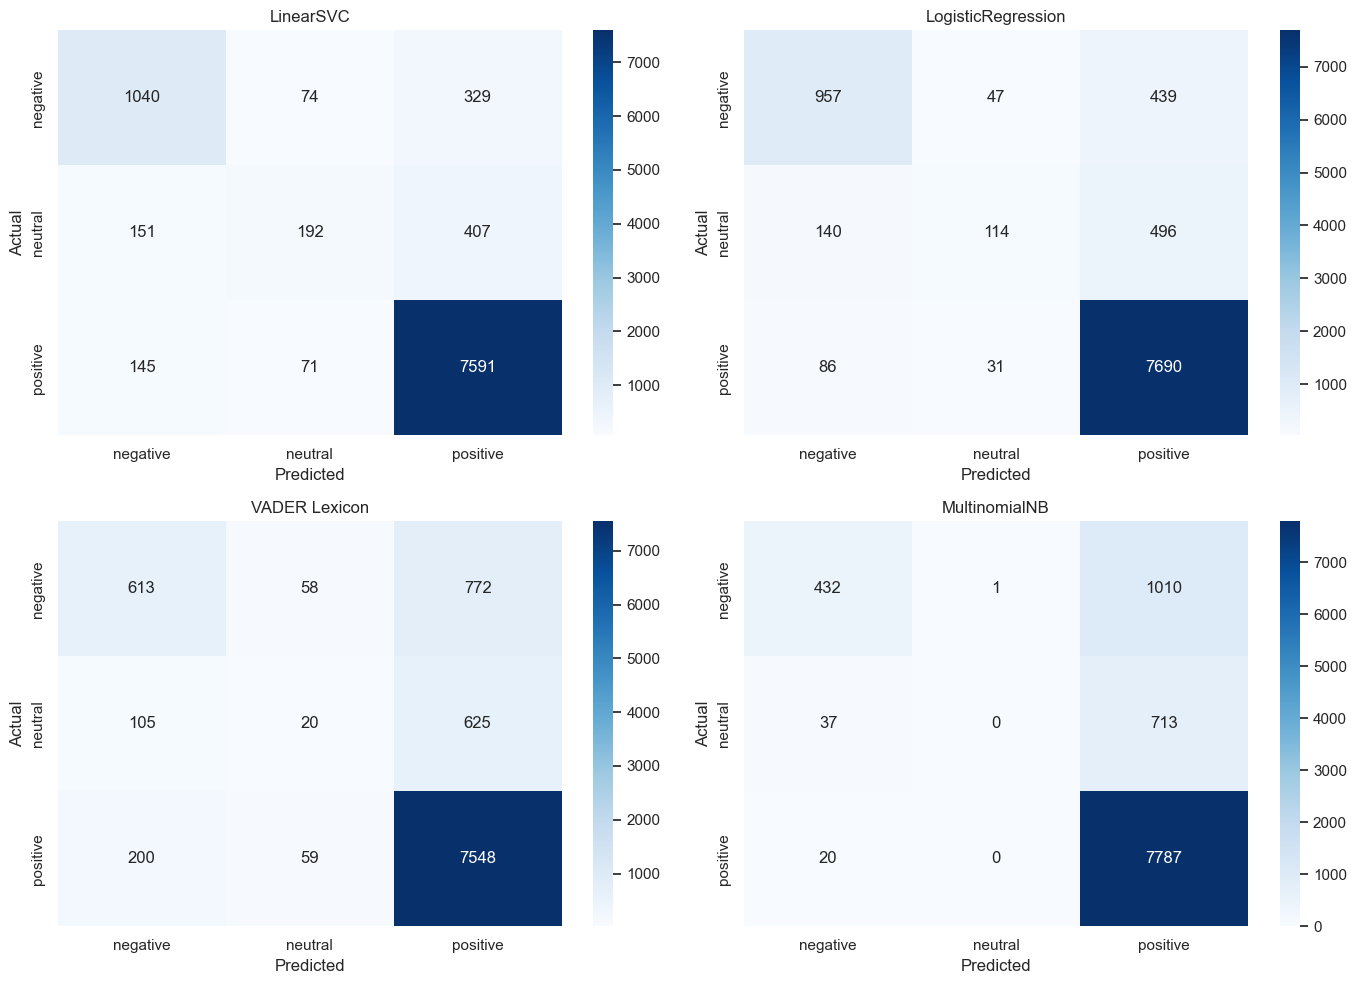

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, model_name in zip(axes, results_df["model"]):
    matrix = confusions[model_name]
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=LABEL_ORDER,
        yticklabels=LABEL_ORDER,
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


## Discussion

The results show that LinearSVC performed best, followed by Logistic Regression, while VADER and MultinomialNB performed lower overall. This indicates that TF-IDF with supervised machine-learning models is more effective for this dataset because these models can learn patterns directly from the review text. In contrast, VADER is simple and fast but depends only on fixed sentiment rules, so it struggles more with context. MultinomialNB was also fast, but its performance was weaker, especially for the neutral class. Overall, machine-learning approaches were more accurate, while lexicon-based methods were easier to use but less reliable for this task.